# Convolutional Neural Networks, CNN

- 이미지 인식과 분류에 있어 강력한 도구

## 픽셀 (Pixel)

- 이미지는 수많은 미세한 점들로 구성된 모자이크와 같으며, 이러한 각 점을 픽셀이라 한다. 
- Picture Element 

- 픽셀은 색의 강도를 나타내는데, 흑백이미지의 경우 각 픽셀은 0부터 255까지의 값을 가진다. 
- 0은 검정색(빛의 부재)를 255는 흰색(빛의 최대 강도)를 나타냅니다. 
- 각 픽셀은 빨강, 초록, 파랑의 세가지 기본 색상을 가지며, 이 색상들의 강도가 결합하여 다양한 색상을 표현. RGB Color model 이라고 함. 

## Resolution 해상도 

- 이미지의 해상도는 이미지의 세부적인 정도, 이미지와 너비와 높이를 픽셀 단위로 표현
- 1920 x 1080 => 너비가 1920 픽셀, 높이가 1080 픽셀 
- 해상도가 높을 수록 이미지에 더 많은 픽셀이 포함되어, 더 세밀한 디테일을 표현할 수 있다. 
- 해상도가 높아짐에 따라 파일 크기도 커지고, 이미지 처리 시간도 길어질수 있다. ( 컴퓨터의 메모리와 처리 능력이 중요 )


## 이미지 데이터 구조(차원) 

- 흑백이미지: H(높이) x W(너비)
- 컬러이미지: H(높이) x W(너비) x 3

## 흑백이미지 불러오기 

- PIL(Pillow)라이브러리의 Image module import 


In [2]:
from PIL import Image
import matplotlib.pyplot as plt

image_grey_path = 'sample_image.png'
image_grey = Image.open(image_grey_path)

## 흑백 이미지 시각화

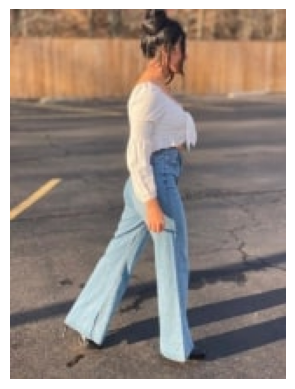

In [4]:
import numpy as np

image_grey = np.array(image_grey) #이미지 데이터를 Numpy 배열로 변환

plt.imshow(image_grey, cmap='gray') #이미지 데이터를 시각화
plt.axis('off') #축을 표시하지 않음
plt.show()

In [10]:
print(f"이미지 해상도: {image_grey.shape[0]} x {image_grey.shape[1]}")
print("이미지 shape:", image_grey.shape)
print("이미지 채널 수:", image_grey.shape[2] if len(image_grey.shape) == 3 else 1)
print(f"이미지 데이터 타입: {image_grey.dtype}")
print(f"이미지 픽셀 값 범위: {image_grey.min()} ~ {image_grey.max()}")
print(image_grey)

이미지 해상도: 212 x 158
이미지 shape: (212, 158, 3)
이미지 채널 수: 3
이미지 데이터 타입: uint8
이미지 픽셀 값 범위: 11 ~ 255
[[[134 111  97]
  [114  92  78]
  [ 88  70  56]
  ...
  [167 133 106]
  [158 122  96]
  [157 121  95]]

 [[137 111  98]
  [119  96  82]
  [ 96  77  63]
  ...
  [161 127 100]
  [155 119  93]
  [154 118  92]]

 [[142 114 100]
  [126 100  85]
  [105  83  69]
  ...
  [166 131 103]
  [159 122  96]
  [157 120  94]]

 ...

 [[129 111 101]
  [133 115 105]
  [128 110  98]
  ...
  [131 116 113]
  [133 118 115]
  [127 112 109]]

 [[118 100  90]
  [125 107  97]
  [125 107  95]
  ...
  [132 117 114]
  [138 123 120]
  [140 125 122]]

 [[126 108  98]
  [132 114 104]
  [131 113 101]
  ...
  [138 123 120]
  [139 124 121]
  [143 128 125]]]


In [18]:
#install opencv-python
import cv2
img = cv2.imread("sample_image.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2.imwrite("output_grey.jpg", gray)



True

# 이미지를 DataFrame으로 변환 및 표시

In [23]:
import pandas as pd

image_grey_path = 'output_grey.png'
image_grey = Image.open(image_grey_path)
print(np.array(image_grey).shape)
image_grey = np.array(image_grey) #이미지 데이터를 Numpy 배열로 변환

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', None)

df_image_grey = pd.DataFrame(image_grey)
df_image_grey

(212, 158)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157
0,116,97,74,63,70,91,118,138,125,116,124,133,128,125,126,119,125,126,119,104,95,97,98,96,97,115,129,129,131,142,152,155,154,154,157,163,162,155,149,147,138,136,127,122,136,148,132,104,103,108,101,96,105,110,107,105,105,111,108,99,104,103,93,99,113,108,107,116,127,131,131,129,131,134,140,139,132,114,88,80,61,114,108,60,64,64,66,69,88,112,134,140,140,144,147,146,125,123,129,144,160,171,167,154,136,124,117,131,157,163,146,129,129,137,138,139,144,140,134,136,137,136,128,122,122,119,111,105,100,101,111,127,137,135,129,127,136,140,133,122,122,129,137,143,131,126,128,140,150,149,155,170,152,143,142,140,131,128
1,117,101,81,71,77,99,128,150,141,124,125,133,128,127,134,135,135,131,119,105,101,108,112,109,98,112,124,126,129,136,144,147,156,155,158,165,168,164,155,149,132,127,116,112,128,143,126,95,92,101,100,96,100,101,100,104,107,111,106,95,94,90,84,97,120,114,111,116,125,130,131,131,131,133,134,132,134,119,87,74,94,124,101,44,39,31,31,35,67,105,140,150,151,154,150,140,118,119,126,136,146,153,151,142,130,126,126,140,160,161,141,123,135,145,149,152,155,146,136,135,128,127,119,113,116,116,107,98,93,95,106,123,135,135,132,131,134,139,134,124,125,132,137,139,132,127,127,138,145,142,146,159,144,134,134,134,127,125
2,121,106,88,79,85,107,137,159,152,129,123,128,125,129,143,151,146,139,125,113,114,122,124,119,108,118,130,138,141,142,142,143,149,150,154,161,168,170,164,156,138,131,116,110,126,140,121,89,84,97,103,101,100,95,94,103,114,116,111,99,92,83,80,98,121,115,111,113,120,126,129,131,133,130,120,115,124,109,72,59,109,117,86,30,26,22,27,36,44,95,142,154,153,155,151,139,125,128,132,132,131,135,138,138,136,139,143,154,166,161,139,122,142,153,159,162,163,151,135,131,127,126,114,105,110,116,110,101,92,95,106,123,134,134,130,128,132,139,135,126,126,131,132,131,133,127,123,129,135,132,136,149,151,138,136,138,131,127
3,129,113,93,84,90,110,135,153,143,126,120,123,125,136,153,159,151,147,139,132,133,137,134,128,124,130,142,156,159,151,142,139,141,147,151,152,155,160,163,161,150,143,128,119,129,138,120,90,86,101,108,108,104,96,95,105,122,126,121,105,97,89,83,99,117,114,111,112,117,123,127,130,123,120,113,115,126,101,60,56,88,91,74,33,31,30,34,38,31,83,133,149,146,144,140,133,133,138,139,132,125,128,140,149,151,154,156,163,171,164,144,130,150,160,163,162,160,144,127,122,133,132,118,104,107,117,117,112,102,106,117,131,139,135,127,121,126,133,131,124,127,132,131,128,132,123,114,116,122,124,133,149,162,146,143,146,139,133
4,138,118,95,86,93,109,127,139,131,127,128,131,136,150,157,152,144,146,146,144,146,149,146,141,140,140,148,160,160,147,134,129,142,150,152,145,139,143,154,163,157,152,140,130,130,131,113,91,96,105,106,102,100,95,96,108,130,136,127,105,99,95,87,95,113,114,114,115,117,120,122,124,113,113,114,124,127,89,46,50,66,70,72,43,39,36,33,29,29,63,103,126,132,130,125,121,128,136,139,133,127,131,142,153,148,148,150,161,171,165,146,135,154,161,160,155,151,136,121,118,135,138,126,110,109,118,121,120,113,117,128,140,146,142,132,124,126,130,128,126,131,135,134,133,129,118,106,105,113,121,137,157,162,146,142,145,139,132
5,141,121,98,90,98,112,125,133,142,142,145,146,146,150,145,131,128,131,134,136,139,145,148,148,150,144,144,150,148,136,125,122,139,146,149,140,131,134,149,163,163,159,149,138,130,119,101,84,101,105,97,89,89,90,96,108,134,140,129,106,101,99,89,93,107,111,115,115,114,114,115,115,114,112,115,123,122,90,60,70,91,82,85,55,42,38,37,33,31,39,57,81,99,109,113,115,120,131,139,139,136,133,133,136,121,122,131,153,169,162,144,135,148,1

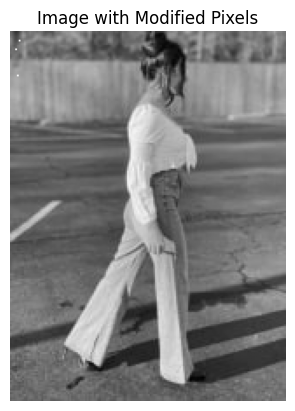

In [24]:
image_grey[5, 5] = 255.0  
image_grey[10, 3] = 255.0
image_grey[25,4] = 255.0

plt.imshow(image_grey, cmap='gray')
plt.axis('off')
plt.title("Image with Modified Pixels")
plt.show()

## 이미지의 해상도 변환과 시각화

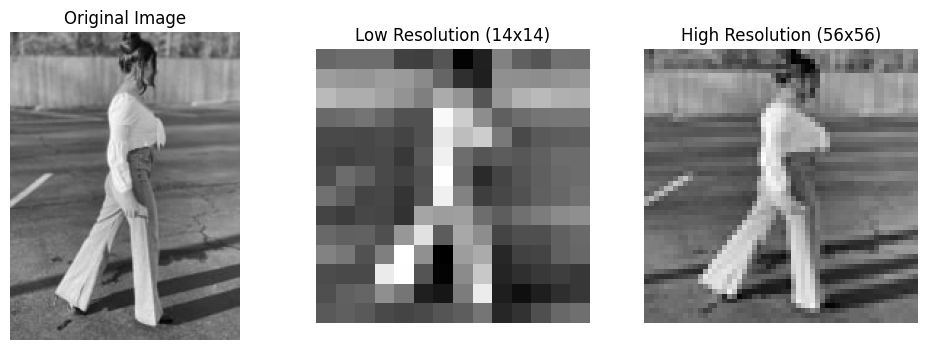

In [28]:
image_grey_path = 'output_grey.png'
original_image = Image.open(image_grey_path)

#원본이미지를 가로14픽셀, 세로 14픽셀의 낮은 해상도로 리사이징합니다. Image.ANTIALIAS 옵션은 리사이징 과정에서 품질 손실을 최소화하기 위해 고급 리샘플링 기술을 사용
low_resolution_image = original_image.resize((14, 14), Image.Resampling.LANCZOS)  # 낮은 해상도
#원본 이미지를 56픽셀로 가로와 세로 모두 확대합니다. 이 옵션도 마찬가지로 이미지의 품질을 유지하도록 도와줍니다. 
high_resolution_image = original_image.resize((56, 56), Image.Resampling.LANCZOS)  # 높은 해상도

# 결과 이미지 표시
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
#figsize 전체 그림 크기를 설정 
#cmap='gray'는 이미지를 흑백으로 표시하도록 설정합니다.
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(low_resolution_image, cmap='gray')
axes[1].set_title('Low Resolution (14x14)')
axes[1].axis('off')

axes[2].imshow(high_resolution_image,cmap='gray')
axes[2].set_title('High Resolution (56x56)')
axes[2].axis('off')

plt.show()

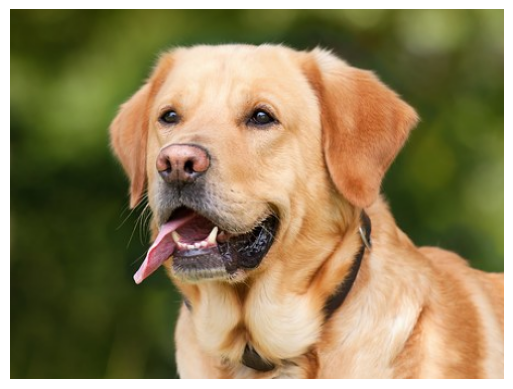

In [29]:
image_path = 'dog.png'
image_color_open = Image.open(image_path)

image_color = np.array(image_color_open)

plt.imshow(image_color)
plt.axis('off') 
plt.show()

In [30]:
print(f"이미지 해상도: {image_color.shape}")
print(f"픽셀 값의 범위: {image_color.min()} to {image_color.max()}")

이미지 해상도: (367, 490, 4)
픽셀 값의 범위: 0 to 255


In [31]:
print(image_color)

[[[ 51  58   6 255]
  [ 53  57   6 255]
  [ 53  57   6 255]
  ...
  [140 147  79 255]
  [140 147  79 255]
  [140 147  79 255]]

 [[ 49  56   4 255]
  [ 51  55   4 255]
  [ 52  56   5 255]
  ...
  [140 147  78 255]
  [140 147  79 255]
  [140 147  79 255]]

 [[ 48  55   4 255]
  [ 49  55   4 255]
  [ 49  55   4 255]
  ...
  [141 148  78 255]
  [141 148  79 255]
  [141 148  79 255]]

 ...

 [[ 56  59  11 255]
  [ 55  58  11 255]
  [ 53  58  12 255]
  ...
  [233 205 178 255]
  [235 205 177 255]
  [233 203 175 255]]

 [[ 57  61  11 255]
  [ 56  59  11 255]
  [ 53  59  11 255]
  ...
  [232 204 177 255]
  [233 203 175 255]
  [233 203 175 255]]

 [[ 57  61  11 255]
  [ 56  59  11 255]
  [ 54  59  12 255]
  ...
  [230 202 175 255]
  [232 202 174 255]
  [232 202 174 255]]]


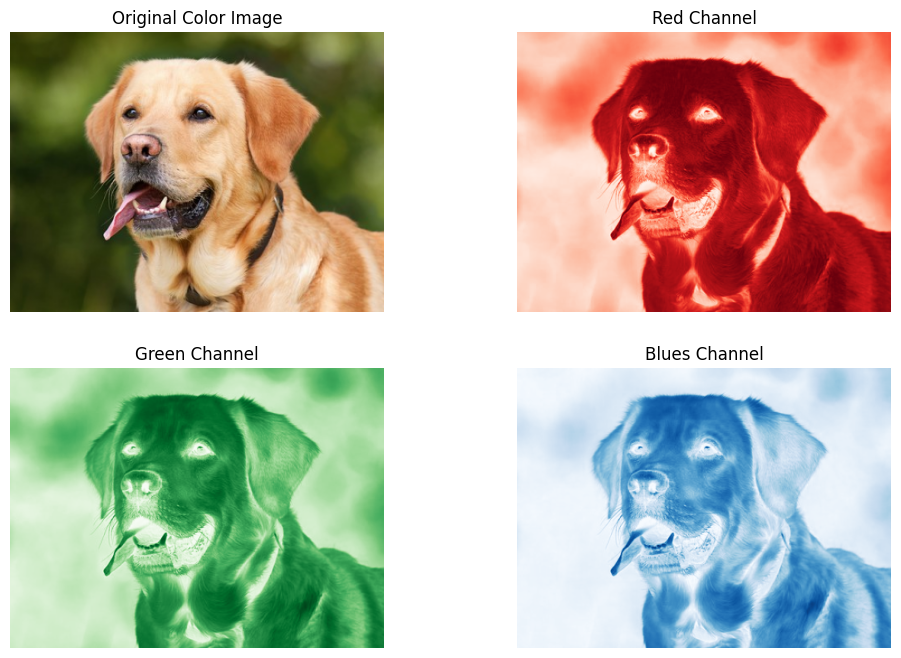

In [33]:
# 컬러 이미지의 RGB 채널 분리
r_channel = image_color[:, :, 0]
g_channel = image_color[:, :, 1]
b_channel = image_color[:, :, 2]

# 원본 컬러 이미지, 흑백 이미지, 그리고 RGB 채널 이미지를 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 원본 컬러 이미지
axes[0, 0].imshow(image_color)
axes[0, 0].set_title("Original Color Image")
axes[0, 0].axis('off')

# R 채널
axes[0, 1].imshow(r_channel, cmap='Reds')
axes[0, 1].set_title("Red Channel")
axes[0, 1].axis('off')
# G 채널
axes[1, 0].imshow(g_channel, cmap='Greens')
axes[1, 0].set_title("Green Channel")
axes[1, 0].axis('off')
# B 채널
user_check = axes[1, 1].imshow(b_channel, cmap='Blues')
axes[1, 1].set_title("Blues Channel")
axes[1, 1].axis('off')

plt.show()